# 🧠 Google Analytics Customer Revenue Prediction
## Phase 1 + 2 — Memory-Efficient Loading, JSON Parsing, Cleaning & EDA (v3 — Enhanced)

> **Competition:** [Google Analytics Customer Revenue Prediction](https://www.kaggle.com/c/ga-customer-revenue-prediction)  
> **Notebook Environment:** Kaggle Notebooks  
> **Goal:** Predict the natural log of total revenue per user for Dec 1, 2018 – Jan 31, 2019

---

### 📌 Notebook Objectives
1. Load data **memory-efficiently** using chunked reading + column skipping
2. Extract high-value signals from the `hits` column before dropping it
3. Flatten all nested JSON columns into usable features
4. Engineer micro-temporal features from `visitStartTime`
5. Clean the data with **conditional, smart imputation**
6. Perform thorough EDA including discriminative & temporal analysis
7. Save clean processed datasets for Phase 3

---

### ⚙️ Memory Strategy
The raw `train_v2.csv` exceeds **30 GB** when fully loaded into RAM.  
We solve this with **two techniques combined**:

| Technique | What it does | Memory saved |
|---|---|---|
| **Extract + drop heavy columns** | Pull vital signals from `hits` then discard; drop `customDimensions` | ~60% reduction |
| **Chunked reading** | Process 50,000 rows at a time, never load full file | Stays under 4 GB |

### 🆕 v3 Upgrades vs v2
| Upgrade | What changed |
|---|---|
| `hits` signal extraction | Count interactions + max eCommerceAction funnel step (instead of blind drop) |
| Micro-temporal features | `visit_hour`, `visit_weekday`, `is_weekend`, `is_business_hours` from `visitStartTime` |
| Smart imputation | Conditional fills: `timeOnSite=0` only for bounced sessions; pageviews fallback chain |
| Deeper EDA | Conversion by city, OS×Device interaction, New vs Returning user revenue |

---

## 📦 Section 1 — Import Libraries

In [1]:
# ── Core ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import json
import os
import re
import gc
import warnings
from datetime import datetime

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='muted')

PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
           '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

print('✅ Libraries imported')
print(f'📅 {datetime.now().strftime("%Y-%m-%d %H:%M")}')

✅ Libraries imported
📅 2026-03-18 17:46


---
## 📂 Section 2 — Paths & Configuration

> **Running on Kaggle Notebooks.**  
> Add the competition data via: **Add Data → ga-customer-revenue-prediction**

In [2]:
# ── Kaggle Paths ──────────────────────────────────────────────────────────────
INPUT_PATH  = '/kaggle/input/competitions/ga-customer-revenue-prediction'
OUTPUT_PATH = '/kaggle/working/'

TRAIN_PATH  = os.path.join(INPUT_PATH, 'train_v2.csv')
TEST_PATH   = os.path.join(INPUT_PATH, 'test_v2.csv')
SAMPLE_SUB  = os.path.join(INPUT_PATH, 'sample_submission_v2.csv')

# ── Loading Config ────────────────────────────────────────────────────────────
CHUNK_SIZE = 50_000   # rows per chunk — safe for Kaggle's 16 GB RAM limit

# We NO LONGER blindly skip hits — we extract signal from it first (see loader).
# customDimensions is still dropped (sparse, low signal).
SKIP_COLS = ['customDimensions']

# JSON columns we WILL parse
JSON_COLS = ['device', 'geoNetwork', 'totals', 'trafficSource']

# ── Verify files ──────────────────────────────────────────────────────────────
print('📁 File check:')
for path, name in [(TRAIN_PATH, 'train_v2.csv'),
                   (TEST_PATH,  'test_v2.csv'),
                   (SAMPLE_SUB, 'sample_submission_v2.csv')]:
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path)/1e9:.2f} GB' if exists else 'NOT FOUND'
    status = '✅' if exists else '❌'
    print(f'   {status}  {name:<35} {size}')

📁 File check:
   ✅  train_v2.csv                        25.41 GB
   ✅  test_v2.csv                         7.62 GB
   ✅  sample_submission_v2.csv            0.01 GB


---
## 🔧 Section 3 — Helper Functions & Memory-Efficient Loader

### Pipeline flow (v3):
```
CSV File (30 GB)
      │
      ▼
Read chunk (50k rows)        ← never loads full file
      │
      ▼
extract_hits_signal()        ← count interactions + max eCommerceAction, THEN drop hits
      │
      ▼
Drop customDimensions
      │
      ▼
Parse JSON columns           ← flatten device, geo, totals, trafficSource
      │
      ▼
engineer_temporal_features() ← hour, weekday, is_weekend, is_business_hours
      │
      ▼
smart_impute()               ← conditional fills based on bounce status
      │
      ▼
Append to list → concat at end  ← final df is lean
```

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# 3A — HITS SIGNAL EXTRACTOR
# ══════════════════════════════════════════════════════════════════════════════

def extract_hits_signal(chunk):
    """
    Extracts high-value signal from the heavy 'hits' column without fully
    parsing the massive nested JSON dictionaries.

    Features created:
      hits_interaction_count      : total number of hit interactions in session
      hits_max_ecommerce_action   : highest funnel step reached
                                    (0=Unknown, 1=Click, 2=View, 3=Add to Cart,
                                     5=Checkout, 6=Purchase)

    A user who reached action_type 3 (add to cart) is exponentially more
    likely to return and generate revenue than a passive page viewer.
    """
    if 'hits' not in chunk.columns:
        return chunk

    # Count hit interactions (often more accurate than totals.hits)
    chunk['hits_interaction_count'] = chunk['hits'].apply(
        lambda x: x.count("'hitNumber':") if isinstance(x, str) else 0
    )

    # Extract maximum eCommerceAction type reached (regex is much faster than
    # json.loads for this massive column)
    def get_max_action_type(hits_str):
        if not isinstance(hits_str, str):
            return 0
        actions = re.findall(r"'action_type': '(\d+)'", hits_str)
        if not actions:
            return 0
        return max(int(a) for a in actions)

    chunk['hits_max_ecommerce_action'] = chunk['hits'].apply(get_max_action_type)

    # Drop the heavy column now that we've extracted what we need
    return chunk.drop(columns=['hits'])


# ══════════════════════════════════════════════════════════════════════════════
# 3B — TEMPORAL FEATURE ENGINEER
# ══════════════════════════════════════════════════════════════════════════════

def engineer_temporal_features(chunk):
    """
    Extracts micro-temporal patterns from the visitStartTime UNIX timestamp.

    Features created:
      visit_hour          : 0–23 hour of day
      visit_weekday       : 0=Monday … 6=Sunday
      is_weekend          : 1 if Saturday or Sunday
      is_business_hours   : 1 if hour is between 9 and 17 (inclusive)

    Insight: buyers often browse on mobile at night but finalize high-ticket
    purchases on desktop during business hours. These features + device type
    create highly predictive interaction terms.
    """
    if 'visitStartTime' not in chunk.columns:
        return chunk

    visit_dt = pd.to_datetime(chunk['visitStartTime'], unit='s')

    chunk['visit_hour']         = visit_dt.dt.hour
    chunk['visit_weekday']      = visit_dt.dt.dayofweek          # 0=Mon, 6=Sun
    chunk['is_weekend']         = visit_dt.dt.dayofweek.isin([5, 6]).astype(int)
    chunk['is_business_hours']  = visit_dt.dt.hour.between(9, 17).astype(int)

    return chunk


# ══════════════════════════════════════════════════════════════════════════════
# 3C — SMART / CONDITIONAL IMPUTER
# ══════════════════════════════════════════════════════════════════════════════

def smart_impute(chunk):
    """
    Conditional missing-value fills based on session behaviour signals.

    Logic:
      bounces    : NaN means they did NOT bounce → fill 0
      pageviews  : fallback chain: NaN → totals.hits → 1
      timeOnSite : 0 only if bounced; otherwise ~100 s approximate median
                   (avoids distorting distribution for engaged non-bounced
                    sessions whose time happened to be missing)
    """
    # bounces NaN  ≡  did not bounce
    if 'totals.bounces' in chunk.columns:
        chunk['totals.bounces'] = chunk['totals.bounces'].fillna(0)

    # pageviews: fallback chain
    if 'totals.pageviews' in chunk.columns:
        if 'totals.hits' in chunk.columns:
            chunk['totals.pageviews'] = (
                chunk['totals.pageviews']
                .fillna(chunk['totals.hits'])
                .fillna(1)
            )
        else:
            chunk['totals.pageviews'] = chunk['totals.pageviews'].fillna(1)

    # timeOnSite: conditional on bounce status
    if 'totals.timeOnSite' in chunk.columns and 'totals.bounces' in chunk.columns:
        bounced_mask = chunk['totals.bounces'] == 1
        chunk.loc[bounced_mask & chunk['totals.timeOnSite'].isna(),
                  'totals.timeOnSite'] = 0
        # Non-bounced sessions with missing time → use approximate median (~100 s)
        chunk['totals.timeOnSite'] = chunk['totals.timeOnSite'].fillna(100)
    elif 'totals.timeOnSite' in chunk.columns:
        chunk['totals.timeOnSite'] = chunk['totals.timeOnSite'].fillna(0)

    # Remaining categorical fills
    fill_unknown = [
        'trafficSource.keyword', 'trafficSource.referralPath',
        'trafficSource.adContent',
        'trafficSource.adwordsClickInfo.adNetworkType',
        'trafficSource.adwordsClickInfo.slot'
    ]
    for col in fill_unknown:
        if col in chunk.columns:
            chunk[col] = chunk[col].fillna('(not set)')

    # Other numeric fills (no conditional logic needed)
    fill_zero = ['totals.newVisits', 'totals.transactions',
                 'totals.sessionQualityDim']
    for col in fill_zero:
        if col in chunk.columns:
            chunk[col] = chunk[col].fillna(0)

    return chunk


# ══════════════════════════════════════════════════════════════════════════════
# 3D — JSON COLUMN PARSER (unchanged from v2)
# ══════════════════════════════════════════════════════════════════════════════

def parse_json_col(series, col_name):
    """Parses a single JSON string column and returns a flat DataFrame."""
    def safe_parse(x):
        try:
            return json.loads(x) if isinstance(x, str) else {}
        except Exception:
            return {}

    parsed = series.apply(safe_parse)
    flat   = pd.json_normalize(parsed.tolist())
    flat.columns = [f'{col_name}.{c}' for c in flat.columns]
    flat.index   = series.index
    return flat


# ══════════════════════════════════════════════════════════════════════════════
# 3E — MAIN CHUNKED LOADER
# ══════════════════════════════════════════════════════════════════════════════

def load_dataset_chunked(path, chunk_size=CHUNK_SIZE, skip_cols=SKIP_COLS,
                         is_test=False):
    """
    Loads a GA dataset CSV memory-efficiently.

    Strategy (v3):
      1. Read CSV in chunks of chunk_size rows
      2. Extract signal from hits column, then drop it
      3. Drop remaining skip_cols (customDimensions)
      4. Parse JSON columns per chunk
      5. Engineer temporal features from visitStartTime
      6. Apply smart conditional imputation
      7. Concatenate lean chunks into final DataFrame

    Parameters:
        path       : path to CSV file
        chunk_size : rows per chunk (default 50,000)
        skip_cols  : columns to drop AFTER hits extraction
        is_test    : set True for test set (skips revenue column handling)

    Returns:
        Flat, feature-rich DataFrame
    """
    print(f'\n📂 Loading: {os.path.basename(path)}')
    print(f'   Chunk size : {chunk_size:,} rows')
    print(f'   Skipping   : {skip_cols}')
    print(f'   Parsing    : {JSON_COLS}')
    print()

    chunks_processed = []
    chunk_num = 0

    reader = pd.read_csv(
        path,
        dtype      = {'fullVisitorId': str},   # CRITICAL: must be string
        chunksize  = chunk_size,
        low_memory = False
    )

    for chunk in reader:
        chunk_num += 1

        # ── Step 1: Extract hits signal, then drop hits ────────────────────
        chunk = extract_hits_signal(chunk)

        # ── Step 2: Drop remaining heavy/useless columns ───────────────────
        cols_to_drop = [c for c in skip_cols if c in chunk.columns]
        if cols_to_drop:
            chunk = chunk.drop(columns=cols_to_drop)

        # ── Step 3: Parse each JSON column ────────────────────────────────
        for col in JSON_COLS:
            if col not in chunk.columns:
                continue
            flat  = parse_json_col(chunk[col], col)
            chunk = chunk.drop(columns=[col])
            chunk = pd.concat([chunk, flat], axis=1)

        # ── Step 4: Convert date column ───────────────────────────────────
        if 'date' in chunk.columns:
            chunk['date'] = pd.to_datetime(chunk['date'], format='%Y%m%d')

        # ── Step 5: Engineer temporal features ────────────────────────────
        chunk = engineer_temporal_features(chunk)

        # ── Step 6: Numeric type coercions ────────────────────────────────
        numeric_cols = [
            'totals.hits', 'totals.pageviews', 'totals.bounces',
            'totals.newVisits', 'totals.sessionQualityDim',
            'totals.timeOnSite', 'totals.transactions', 'visitNumber'
        ]
        for col in numeric_cols:
            if col in chunk.columns:
                chunk[col] = pd.to_numeric(chunk[col], errors='coerce')

        # ── Step 7: Smart imputation ───────────────────────────────────────
        chunk = smart_impute(chunk)

        chunks_processed.append(chunk)

        # Progress update every 10 chunks
        if chunk_num % 10 == 0:
            rows_so_far = chunk_num * chunk_size
            print(f'   ✔ Chunk {chunk_num:>4}  (~{rows_so_far:>10,} rows processed)')

        del chunk
        gc.collect()

    print(f'\n   ✅ All {chunk_num} chunks processed. Concatenating...')
    df = pd.concat(chunks_processed, ignore_index=True)

    del chunks_processed
    gc.collect()

    print(f'   ✅ Final shape: {df.shape}')
    if 'date' in df.columns:
        print(f'   📅 Date range: {df["date"].min().date()} → {df["date"].max().date()}')
    print(f'   👤 Unique users: {df["fullVisitorId"].nunique():,}')
    return df


print('✅ All helper functions defined')

✅ All helper functions defined


---
## 📥 Section 4 — Load Train & Test

In [4]:
# ── Load Training Data ────────────────────────────────────────────────────────
# Period: August 1, 2016 → April 30, 2018
train = load_dataset_chunked(TRAIN_PATH)

print('\n' + '='*55)
print(f'  TRAIN loaded successfully')
print(f'  Shape        : {train.shape}')
print(f'  Memory usage : {train.memory_usage(deep=True).sum() / 1e9:.2f} GB')
print('='*55)


📂 Loading: train_v2.csv
   Chunk size : 50,000 rows
   Skipping   : ['customDimensions']
   Parsing    : ['device', 'geoNetwork', 'totals', 'trafficSource']

   ✔ Chunk   10  (~   500,000 rows processed)
   ✔ Chunk   20  (~ 1,000,000 rows processed)
   ✔ Chunk   30  (~ 1,500,000 rows processed)

   ✅ All 35 chunks processed. Concatenating...
   ✅ Final shape: (1708337, 64)
   📅 Date range: 2016-08-01 → 2018-04-30
   👤 Unique users: 1,323,730

  TRAIN loaded successfully
  Shape        : (1708337, 64)
  Memory usage : 5.15 GB


In [5]:
# ── Load Test Data ────────────────────────────────────────────────────────────
# Period: May 1, 2018 → October 15, 2018
# We predict for: December 1, 2018 → January 31, 2019 (future)
test = load_dataset_chunked(TEST_PATH, is_test=True)

print('\n' + '='*55)
print(f'  TEST loaded successfully')
print(f'  Shape        : {test.shape}')
print(f'  Memory usage : {test.memory_usage(deep=True).sum() / 1e9:.2f} GB')
print('='*55)


📂 Loading: test_v2.csv
   Chunk size : 50,000 rows
   Skipping   : ['customDimensions']
   Parsing    : ['device', 'geoNetwork', 'totals', 'trafficSource']


   ✅ All 9 chunks processed. Concatenating...
   ✅ Final shape: (401589, 63)
   📅 Date range: 2018-05-01 → 2018-10-15
   👤 Unique users: 296,530

  TEST loaded successfully
  Shape        : (401589, 63)
  Memory usage : 1.20 GB


In [6]:
# ── Review all available columns ─────────────────────────────────────────────
print(f'📋 Columns after loading + feature engineering ({len(train.columns)} total):\n')
for i, col in enumerate(sorted(train.columns), 1):
    print(f'  {i:>3}. {col}')

# Verify new columns exist
print()
new_cols = ['hits_interaction_count', 'hits_max_ecommerce_action',
            'visit_hour', 'visit_weekday', 'is_weekend', 'is_business_hours']
for col in new_cols:
    status = '✅' if col in train.columns else '❌ MISSING'
    print(f'  {status}  {col}')

📋 Columns after loading + feature engineering (64 total):

    1. channelGrouping
    2. date
    3. device.browser
    4. device.browserSize
    5. device.browserVersion
    6. device.deviceCategory
    7. device.flashVersion
    8. device.isMobile
    9. device.language
   10. device.mobileDeviceBranding
   11. device.mobileDeviceInfo
   12. device.mobileDeviceMarketingName
   13. device.mobileDeviceModel
   14. device.mobileInputSelector
   15. device.operatingSystem
   16. device.operatingSystemVersion
   17. device.screenColors
   18. device.screenResolution
   19. fullVisitorId
   20. geoNetwork.city
   21. geoNetwork.cityId
   22. geoNetwork.continent
   23. geoNetwork.country
   24. geoNetwork.latitude
   25. geoNetwork.longitude
   26. geoNetwork.metro
   27. geoNetwork.networkDomain
   28. geoNetwork.networkLocation
   29. geoNetwork.region
   30. geoNetwork.subContinent
   31. hits_interaction_count
   32. hits_max_ecommerce_action
   33. is_business_hours
   34. is_weekend


---
## 🧹 Section 5 — Data Cleaning

| Step | Action |
|---|---|
| 1 | Handle `transactionRevenue` → numeric, NaN → 0 |
| 2 | Create log target variable |
| 3 | Drop constant columns |
| 4 | Drop duplicate rows (sanity check) |

> **Note:** Numeric coercions and smart imputation are now done **inside the loader** per chunk,  
> which saves memory vs doing them on the full concatenated DataFrame.

In [7]:
# ── Step 1 & 2: Revenue + Target ─────────────────────────────────────────────
print('💰 Revenue Column Analysis')
print('─'*45)

train['totals.transactionRevenue'] = pd.to_numeric(
    train['totals.transactionRevenue'], errors='coerce'
)

total   = len(train)
has_rev = train['totals.transactionRevenue'].notna().sum()
no_rev  = total - has_rev

print(f'  Total visits          : {total:>12,}')
print(f'  Visits WITH revenue   : {has_rev:>12,}  ({has_rev/total*100:.2f}%)')
print(f'  Visits WITHOUT revenue: {no_rev:>12,}  ({no_rev/total*100:.2f}%)')
print()
print('  ⚠️  KEY INSIGHT: ~98% of visits = zero revenue.')
print('  This is a ZERO-INFLATED problem. Most users never buy.')

# Fill NaN → 0
train['totals.transactionRevenue'] = train['totals.transactionRevenue'].fillna(0)

# Create target variables
train['revenue']     = train['totals.transactionRevenue']
train['log_revenue'] = np.log1p(train['revenue'])

print(f'\n  ✅ Created: revenue, log_revenue')
print(f'\n  Revenue stats (non-zero only):')
print(train[train['revenue'] > 0]['revenue'].describe())

💰 Revenue Column Analysis
─────────────────────────────────────────────
  Total visits          :    1,708,337
  Visits WITH revenue   :       18,514  (1.08%)
  Visits WITHOUT revenue:    1,689,823  (98.92%)

  ⚠️  KEY INSIGHT: ~98% of visits = zero revenue.
  This is a ZERO-INFLATED problem. Most users never buy.

  ✅ Created: revenue, log_revenue

  Revenue stats (non-zero only):
count         18514.0000
mean      125113156.5302
std       416265269.2781
min           10000.0000
25%        23067500.0000
50%        46060000.0000
75%       100000000.0000
max     23129500000.0000
Name: revenue, dtype: float64


In [8]:
# ── Step 3: Drop Constant Columns ────────────────────────────────────────────
const_cols = [c for c in train.columns if train[c].nunique(dropna=False) <= 1]

if const_cols:
    print(f'🗑️  Dropping {len(const_cols)} constant columns:')
    for c in const_cols:
        print(f'   - {c}')
    train = train.drop(columns=const_cols)
    test  = test.drop(columns=[c for c in const_cols if c in test.columns])
else:
    print('✅ No constant columns found')

# ── Step 4: Sanity check — duplicate rows ─────────────────────────────────────
dupes = train.duplicated().sum()
print(f'\n🔍 Duplicate rows in train: {dupes:,}')
if dupes > 0:
    train = train.drop_duplicates()
    print(f'   ✅ Removed. New shape: {train.shape}')

🗑️  Dropping 19 constant columns:
   - socialEngagementType
   - device.browserVersion
   - device.browserSize
   - device.operatingSystemVersion
   - device.mobileDeviceBranding
   - device.mobileDeviceModel
   - device.mobileInputSelector
   - device.mobileDeviceInfo
   - device.mobileDeviceMarketingName
   - device.flashVersion
   - device.language
   - device.screenColors
   - device.screenResolution
   - geoNetwork.cityId
   - geoNetwork.latitude
   - geoNetwork.longitude
   - geoNetwork.networkLocation
   - totals.visits
   - trafficSource.adwordsClickInfo.criteriaParameters

🔍 Duplicate rows in train: 0


In [9]:
# ── Memory cleanup after cleaning ────────────────────────────────────────────
gc.collect()
print(f'🧠 Memory after cleaning:')
print(f'   train: {train.memory_usage(deep=True).sum() / 1e9:.2f} GB  shape: {train.shape}')
print(f'   test : {test.memory_usage(deep=True).sum()  / 1e9:.2f} GB  shape: {test.shape}')

# Quick preview
print()
print('📋 Sample columns — new features:')
new_cols = ['hits_interaction_count', 'hits_max_ecommerce_action',
            'visit_hour', 'visit_weekday', 'is_weekend', 'is_business_hours']
available = [c for c in new_cols if c in train.columns]
print(train[available].head(3))

🧠 Memory after cleaning:
   train: 2.67 GB  shape: (1708337, 47)
   test : 0.62 GB  shape: (401589, 44)

📋 Sample columns — new features:
   hits_interaction_count  hits_max_ecommerce_action  visit_hour  \
0                       1                          0           0   
1                       2                          0          17   
2                       2                          0           0   

   visit_weekday  is_weekend  is_business_hours  
0              1           0                  0  
1              0           0                  1  
2              1           0                  0  


---
## 📊 Section 6 — Exploratory Data Analysis

> Each plot answers a specific **business question.**  
> v3 adds deeper discriminative EDA on top of the original 6 plots.

### 6.1 — Zero-Inflation: The Core Challenge

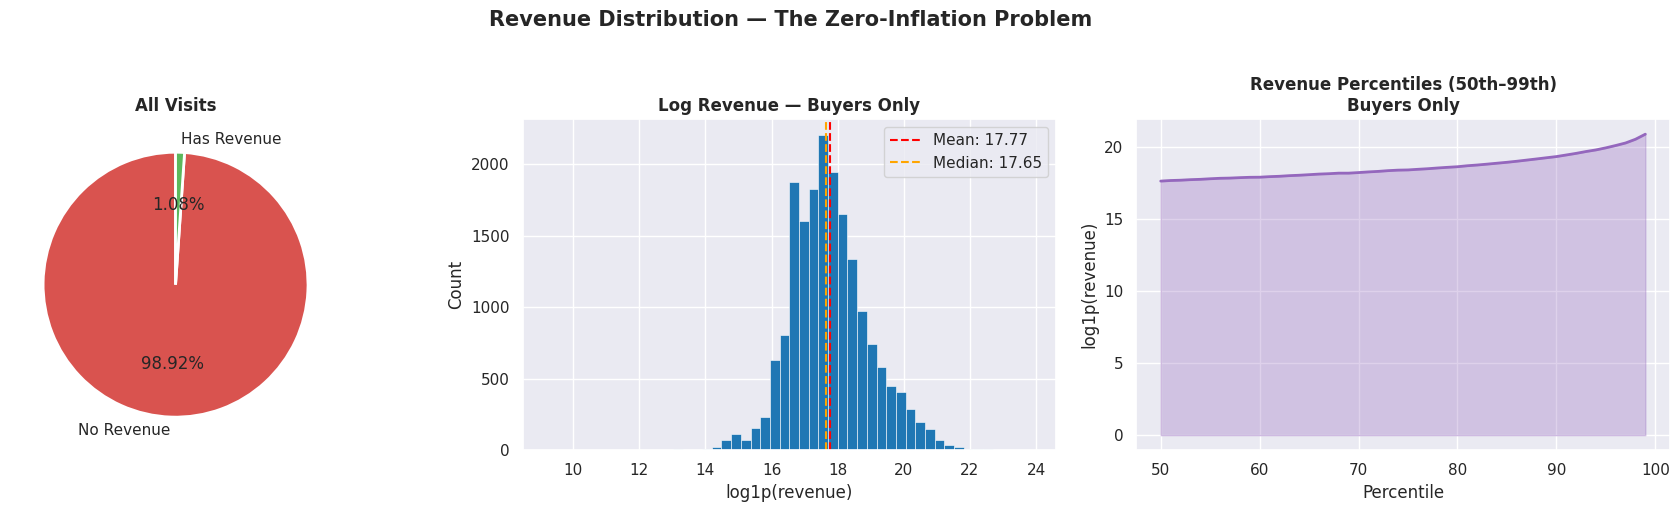


💡 Business Insight:
   ~98% of visits generate zero revenue.
   A two-step model (classify buyer → predict amount) will outperform
   a single regression model on this data.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Revenue Distribution — The Zero-Inflation Problem',
             fontsize=15, fontweight='bold', y=1.02)

# Pie: zero vs non-zero visits
counts = pd.Series({
    'No Revenue': (train['revenue'] == 0).sum(),
    'Has Revenue': (train['revenue'] > 0).sum()
})
axes[0].pie(counts, labels=counts.index, autopct='%1.2f%%',
            colors=['#d9534f', '#5cb85c'],
            wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[0].set_title('All Visits', fontweight='bold')

# Histogram: log revenue of buyers
buyers = train[train['revenue'] > 0]['log_revenue']
axes[1].hist(buyers, bins=50, color='#1f77b4', edgecolor='white', linewidth=0.4)
axes[1].axvline(buyers.mean(),   color='red',    linestyle='--',
                label=f'Mean: {buyers.mean():.2f}')
axes[1].axvline(buyers.median(), color='orange', linestyle='--',
                label=f'Median: {buyers.median():.2f}')
axes[1].set_title('Log Revenue — Buyers Only', fontweight='bold')
axes[1].set_xlabel('log1p(revenue)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Revenue distribution by percentile
pcts     = np.arange(50, 100, 1)
pct_vals = np.percentile(train[train['revenue'] > 0]['revenue'], pcts)
axes[2].plot(pcts, np.log1p(pct_vals), color='#9467bd', linewidth=2)
axes[2].fill_between(pcts, np.log1p(pct_vals), alpha=0.3, color='#9467bd')
axes[2].set_title('Revenue Percentiles (50th–99th)\nBuyers Only', fontweight='bold')
axes[2].set_xlabel('Percentile')
axes[2].set_ylabel('log1p(revenue)')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'plot_01_revenue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Business Insight:')
print('   ~98% of visits generate zero revenue.')
print('   A two-step model (classify buyer → predict amount) will outperform')
print('   a single regression model on this data.')

### 6.2 — Channel Grouping: Traffic vs Revenue

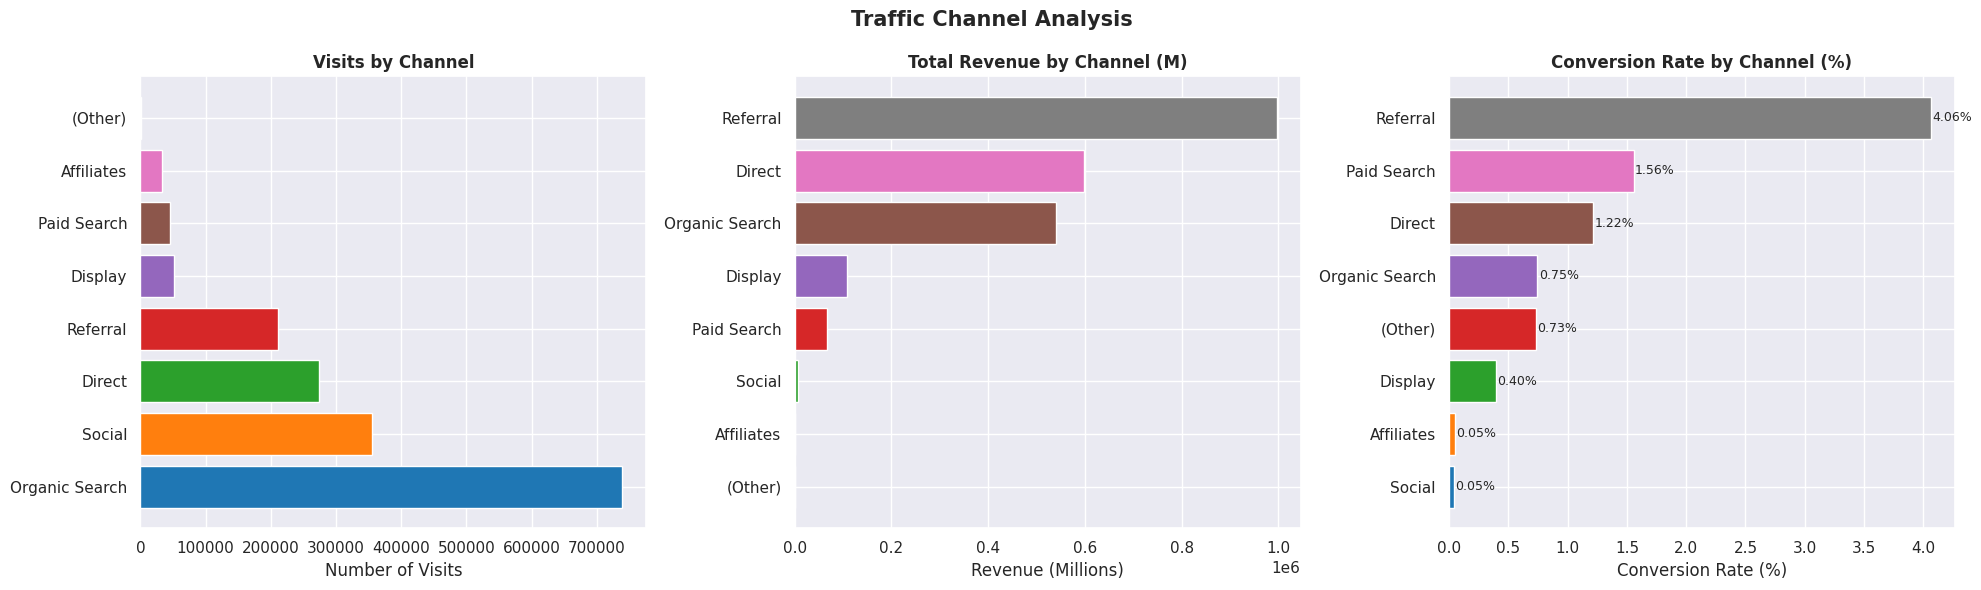

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Traffic Channel Analysis', fontsize=15, fontweight='bold')

channel_visits = train['channelGrouping'].value_counts()
channel_rev    = train.groupby('channelGrouping')['revenue'].sum().sort_values(ascending=True)
channel_conv   = train.groupby('channelGrouping').apply(
    lambda x: (x['revenue'] > 0).sum() / len(x) * 100
).sort_values(ascending=True)

axes[0].barh(channel_visits.index, channel_visits.values,
             color=PALETTE[:len(channel_visits)])
axes[0].set_title('Visits by Channel', fontweight='bold')
axes[0].set_xlabel('Number of Visits')

axes[1].barh(channel_rev.index, channel_rev.values / 1e6,
             color=PALETTE[:len(channel_rev)])
axes[1].set_title('Total Revenue by Channel (M)', fontweight='bold')
axes[1].set_xlabel('Revenue (Millions)')

axes[2].barh(channel_conv.index, channel_conv.values,
             color=PALETTE[:len(channel_conv)])
axes[2].set_title('Conversion Rate by Channel (%)', fontweight='bold')
axes[2].set_xlabel('Conversion Rate (%)')
for i, v in enumerate(channel_conv.values):
    axes[2].text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'plot_02_channel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 — Device: Desktop vs Mobile vs Tablet

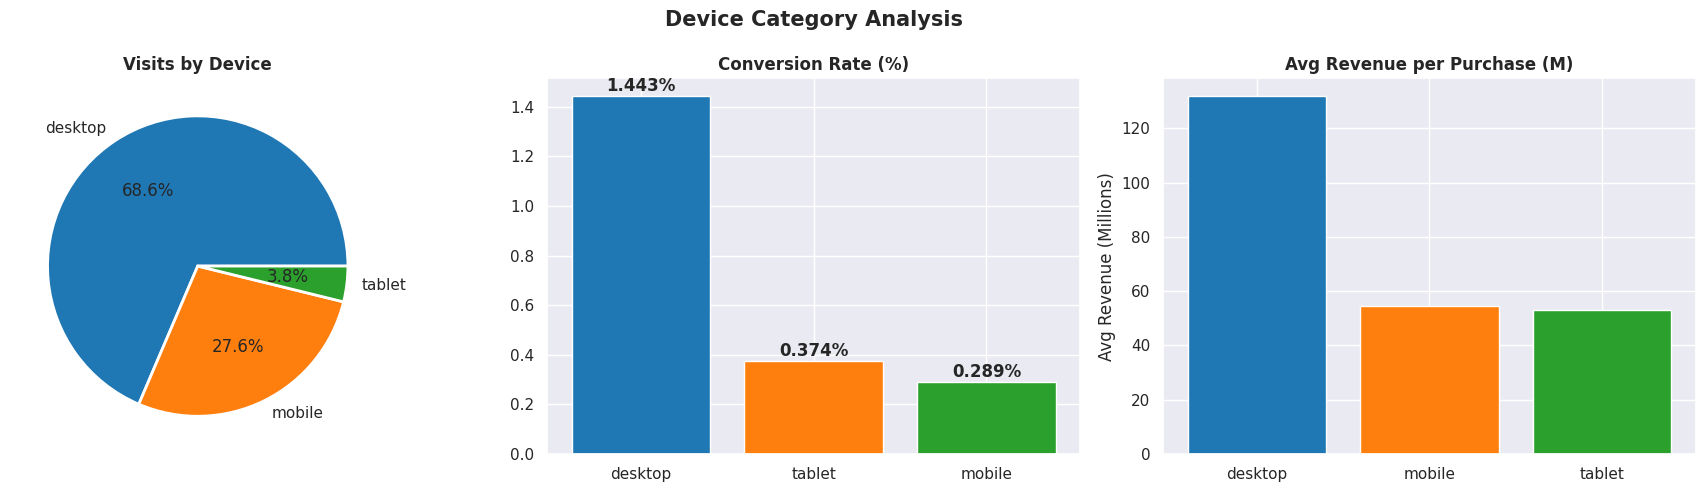


💡 Business Insight:
   Desktop has highest conversion rate.
   Mobile drives traffic volume but low purchase intent.


In [12]:
if 'device.deviceCategory' in train.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Device Category Analysis', fontsize=15, fontweight='bold')

    dev_visits  = train['device.deviceCategory'].value_counts()
    dev_conv    = train.groupby('device.deviceCategory').apply(
        lambda x: (x['revenue'] > 0).sum() / len(x) * 100
    ).sort_values(ascending=False)
    dev_avg_rev = (
        train[train['revenue'] > 0]
        .groupby('device.deviceCategory')['revenue'].mean() / 1e6
    )

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    axes[0].pie(dev_visits, labels=dev_visits.index, autopct='%1.1f%%',
                colors=colors, wedgeprops=dict(edgecolor='white', linewidth=2))
    axes[0].set_title('Visits by Device', fontweight='bold')

    axes[1].bar(dev_conv.index, dev_conv.values, color=colors)
    axes[1].set_title('Conversion Rate (%)', fontweight='bold')
    for i, v in enumerate(dev_conv.values):
        axes[1].text(i, v + 0.02, f'{v:.3f}%', ha='center', fontweight='bold')

    if not dev_avg_rev.empty:
        axes[2].bar(dev_avg_rev.index, dev_avg_rev.values, color=colors)
        axes[2].set_title('Avg Revenue per Purchase (M)', fontweight='bold')
        axes[2].set_ylabel('Avg Revenue (Millions)')

    plt.tight_layout()
    plt.savefig(OUTPUT_PATH + 'plot_03_device_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n💡 Business Insight:')
    print('   Desktop has highest conversion rate.')
    print('   Mobile drives traffic volume but low purchase intent.')

### 6.4 — Geography: Top Revenue Countries

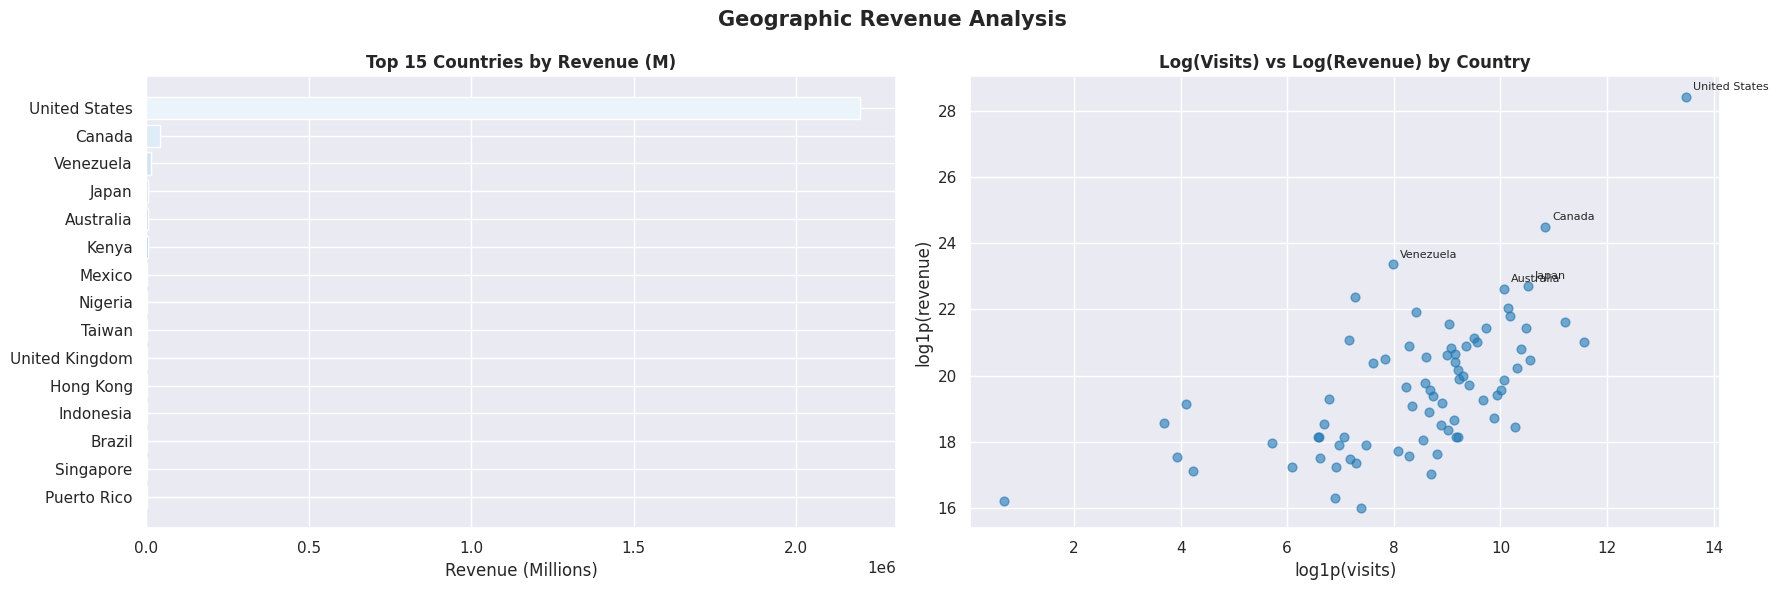

In [13]:
if 'geoNetwork.country' in train.columns:
    top_countries = (
        train.groupby('geoNetwork.country')['revenue']
        .sum().sort_values(ascending=False).head(15)
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Geographic Revenue Analysis', fontsize=15, fontweight='bold')

    axes[0].barh(
        top_countries.index[::-1],
        top_countries.values[::-1] / 1e6,
        color=sns.color_palette('Blues_r', len(top_countries))
    )
    axes[0].set_title('Top 15 Countries by Revenue (M)', fontweight='bold')
    axes[0].set_xlabel('Revenue (Millions)')

    cs = train.groupby('geoNetwork.country').agg(
        visits=('fullVisitorId', 'count'),
        revenue=('revenue', 'sum')
    ).reset_index()
    cs = cs[cs['revenue'] > 0]

    axes[1].scatter(np.log1p(cs['visits']), np.log1p(cs['revenue']),
                    alpha=0.6, color='#1f77b4', s=40)
    axes[1].set_title('Log(Visits) vs Log(Revenue) by Country', fontweight='bold')
    axes[1].set_xlabel('log1p(visits)')
    axes[1].set_ylabel('log1p(revenue)')

    for _, row in cs.nlargest(5, 'revenue').iterrows():
        axes[1].annotate(
            row['geoNetwork.country'],
            (np.log1p(row['visits']), np.log1p(row['revenue'])),
            xytext=(5, 5), textcoords='offset points', fontsize=8
        )

    plt.tight_layout()
    plt.savefig(OUTPUT_PATH + 'plot_04_geo_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6.5 — Time Series: Seasonality & Trends

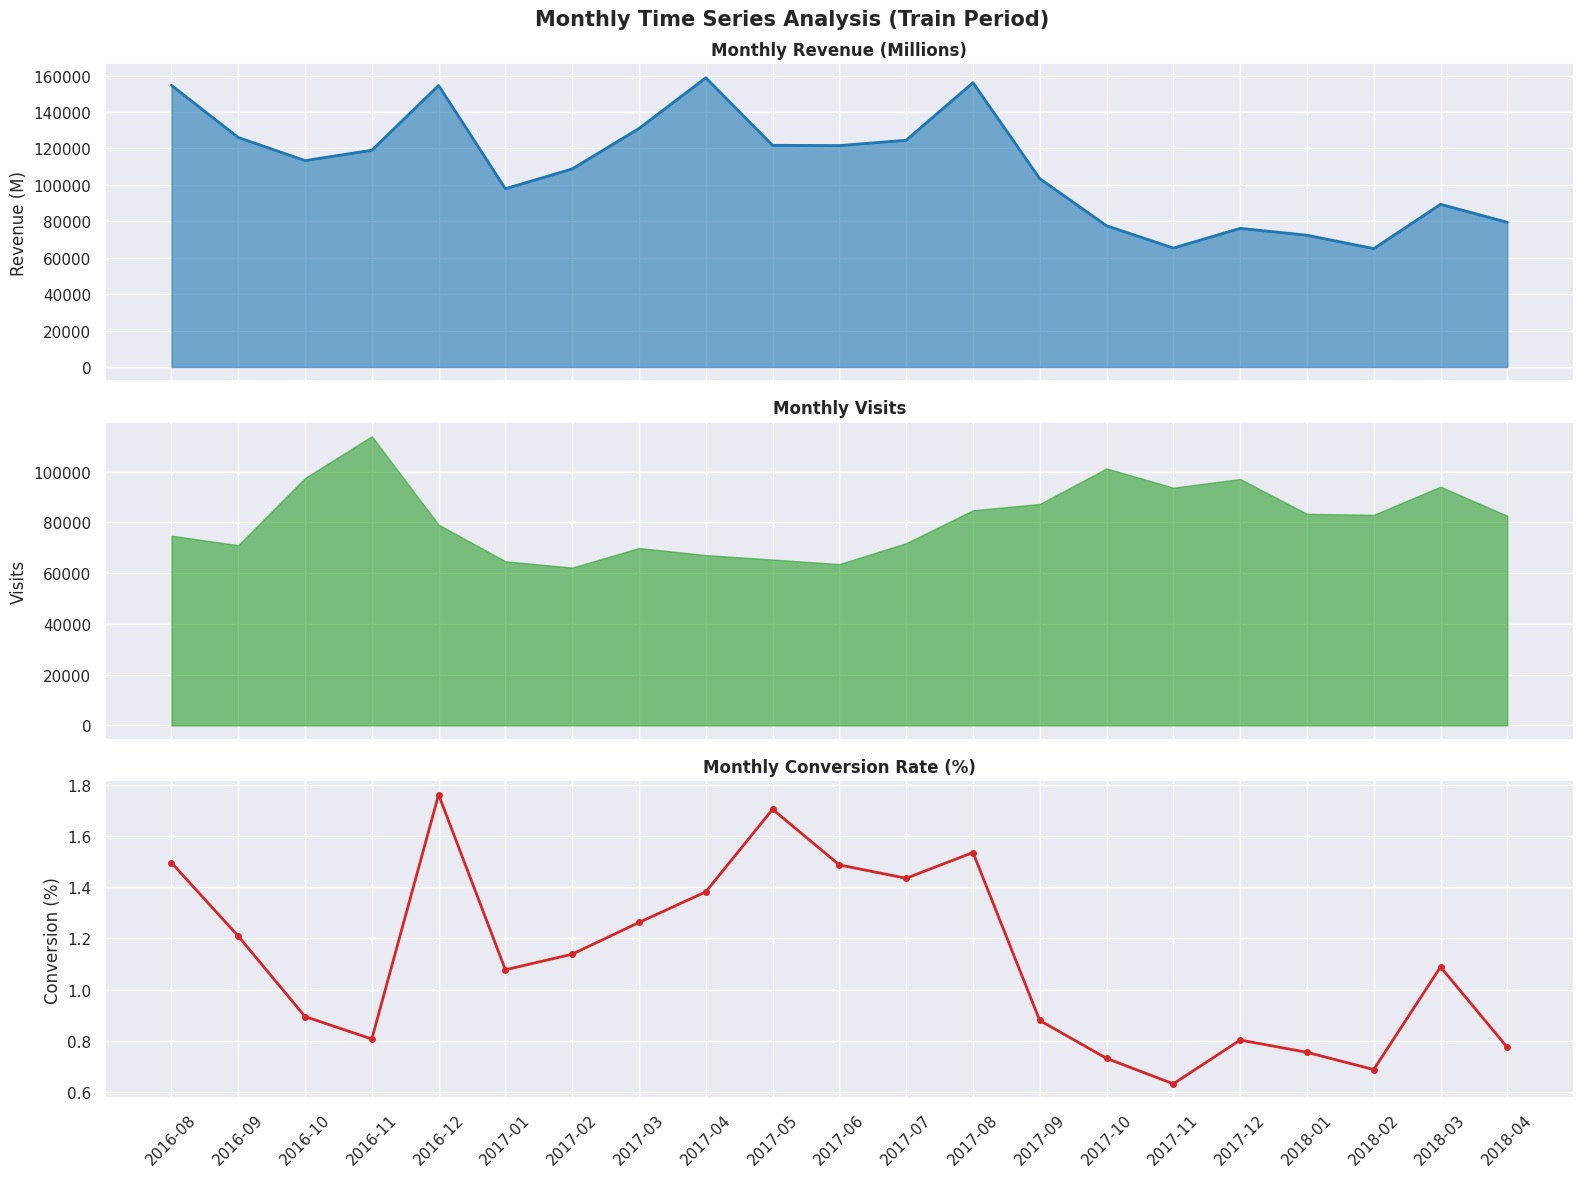


💡 Business Insight:
   Look for Q4 holiday spikes (Nov–Dec).
   Conversion rate fluctuates independently from visit volume.
   Seasonal patterns must be captured in feature engineering.


In [14]:
train['year_month'] = train['date'].dt.to_period('M')
monthly = train.groupby('year_month').agg(
    total_revenue=('revenue', 'sum'),
    total_visits=('fullVisitorId', 'count'),
    buyers=('revenue', lambda x: (x > 0).sum())
).reset_index()
monthly['ym_str']          = monthly['year_month'].astype(str)
monthly['conversion_rate'] = monthly['buyers'] / monthly['total_visits'] * 100

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Monthly Time Series Analysis (Train Period)',
             fontsize=15, fontweight='bold')

axes[0].fill_between(monthly['ym_str'], monthly['total_revenue']/1e6,
                     alpha=0.6, color='#1f77b4')
axes[0].plot(monthly['ym_str'], monthly['total_revenue']/1e6,
             color='#1f77b4', linewidth=2)
axes[0].set_title('Monthly Revenue (Millions)', fontweight='bold')
axes[0].set_ylabel('Revenue (M)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].fill_between(monthly['ym_str'], monthly['total_visits'],
                     alpha=0.6, color='#2ca02c')
axes[1].set_title('Monthly Visits', fontweight='bold')
axes[1].set_ylabel('Visits')
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(monthly['ym_str'], monthly['conversion_rate'],
             color='#d62728', linewidth=2, marker='o', markersize=4)
axes[2].set_title('Monthly Conversion Rate (%)', fontweight='bold')
axes[2].set_ylabel('Conversion (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'plot_05_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Business Insight:')
print('   Look for Q4 holiday spikes (Nov–Dec).')
print('   Conversion rate fluctuates independently from visit volume.')
print('   Seasonal patterns must be captured in feature engineering.')

### 6.6 — Session Behavior: Do Engaged Users Buy More?

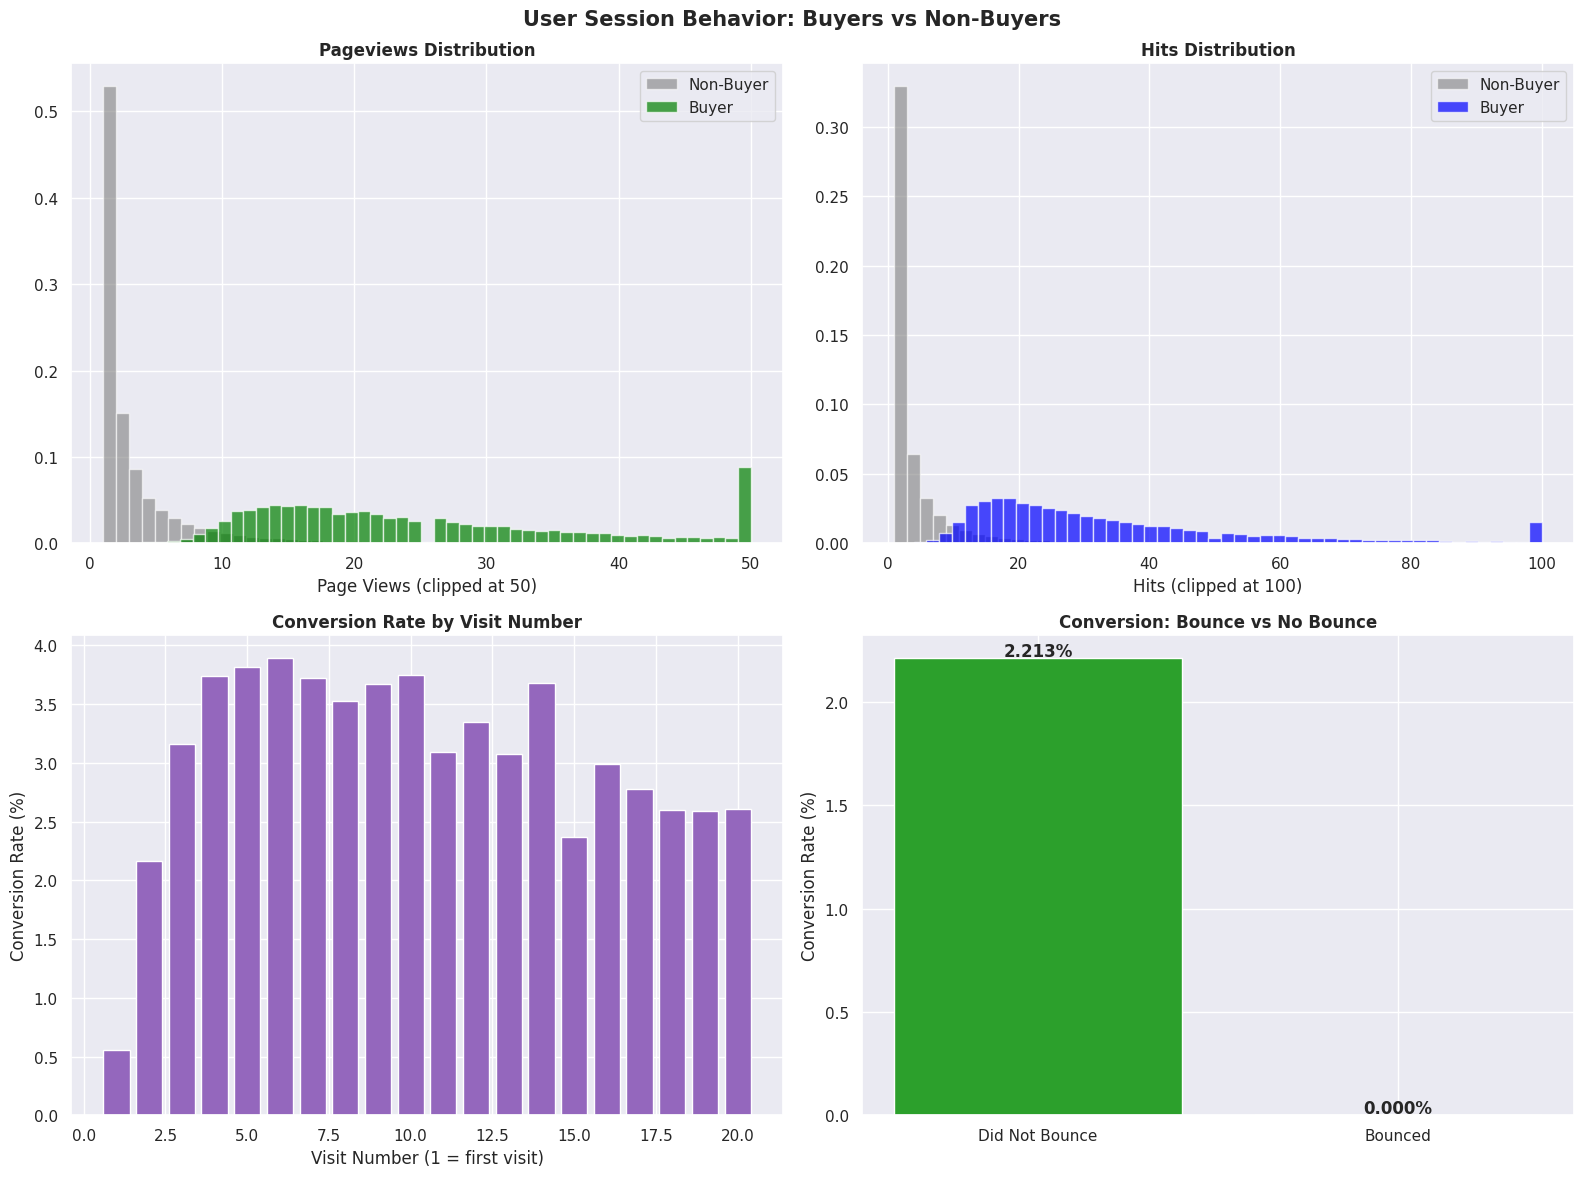

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('User Session Behavior: Buyers vs Non-Buyers',
             fontsize=15, fontweight='bold')

buyer_mask = train['revenue'] > 0

if 'totals.pageviews' in train.columns:
    axes[0,0].hist(train[~buyer_mask]['totals.pageviews'].clip(0,50),
                   bins=50, alpha=0.6, color='gray',  label='Non-Buyer', density=True)
    axes[0,0].hist(train[buyer_mask]['totals.pageviews'].clip(0,50),
                   bins=50, alpha=0.7, color='green', label='Buyer',     density=True)
    axes[0,0].set_title('Pageviews Distribution', fontweight='bold')
    axes[0,0].set_xlabel('Page Views (clipped at 50)')
    axes[0,0].legend()

if 'totals.hits' in train.columns:
    axes[0,1].hist(train[~buyer_mask]['totals.hits'].clip(0,100),
                   bins=50, alpha=0.6, color='gray', label='Non-Buyer', density=True)
    axes[0,1].hist(train[buyer_mask]['totals.hits'].clip(0,100),
                   bins=50, alpha=0.7, color='blue', label='Buyer',     density=True)
    axes[0,1].set_title('Hits Distribution', fontweight='bold')
    axes[0,1].set_xlabel('Hits (clipped at 100)')
    axes[0,1].legend()

if 'visitNumber' in train.columns:
    vn = train.groupby('visitNumber').agg(
        visits=('revenue','count'),
        buyers=('revenue', lambda x: (x>0).sum())
    ).head(20).reset_index()
    vn['conv'] = vn['buyers'] / vn['visits'] * 100
    axes[1,0].bar(vn['visitNumber'], vn['conv'], color='#9467bd')
    axes[1,0].set_title('Conversion Rate by Visit Number', fontweight='bold')
    axes[1,0].set_xlabel('Visit Number (1 = first visit)')
    axes[1,0].set_ylabel('Conversion Rate (%)')

if 'totals.bounces' in train.columns:
    bc = train.groupby('totals.bounces').apply(
        lambda x: (x['revenue'] > 0).mean() * 100
    ).reset_index()
    bc.columns = ['bounced', 'conv']
    bc['label'] = bc['bounced'].map({0.0: 'Did Not Bounce', 1.0: 'Bounced'})
    axes[1,1].bar(bc['label'], bc['conv'], color=['#2ca02c', '#d62728'])
    axes[1,1].set_title('Conversion: Bounce vs No Bounce', fontweight='bold')
    axes[1,1].set_ylabel('Conversion Rate (%)')
    for i, v in enumerate(bc['conv']):
        axes[1,1].text(i, v + 0.01, f'{v:.3f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'plot_06_user_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.7 — 🆕 Micro-Temporal Patterns: When Do Buyers Visit?

> **New in v3.** These features help differentiate B2B (business-hours desktop) from B2C (evening mobile) buyers.

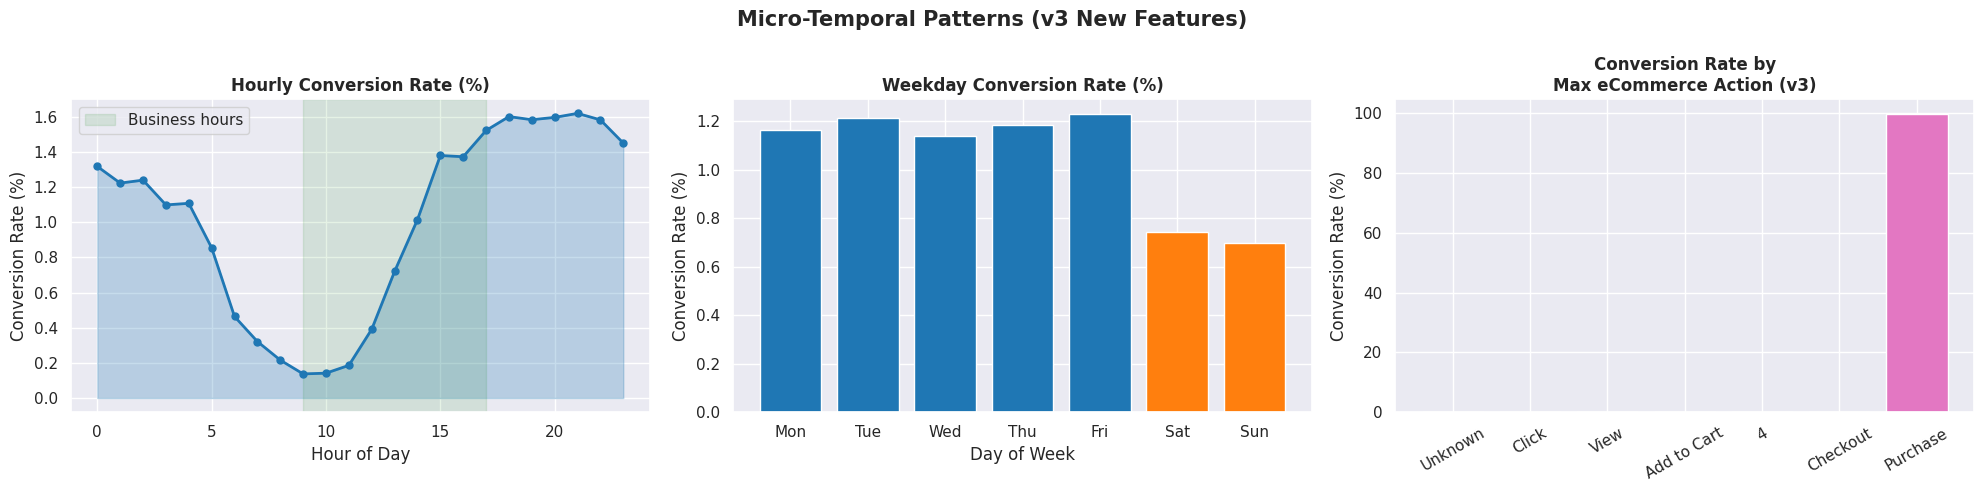


💡 Business Insight:
   Peak conversion hours and high funnel actions (Add to Cart, Checkout)
   are strong predictors of future revenue. Use these in Phase 3 aggregations.


In [16]:
if 'visit_hour' in train.columns:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle('Micro-Temporal Patterns (v3 New Features)', fontsize=15, fontweight='bold')

    buyer_mask = train['revenue'] > 0

    # Hourly conversion rate
    hourly_conv = train.groupby('visit_hour').apply(
        lambda x: (x['revenue'] > 0).mean() * 100
    )
    axes[0].plot(hourly_conv.index, hourly_conv.values, color='#1f77b4',
                 linewidth=2, marker='o', markersize=5)
    axes[0].fill_between(hourly_conv.index, hourly_conv.values, alpha=0.25,
                         color='#1f77b4')
    axes[0].axvspan(9, 17, alpha=0.1, color='green', label='Business hours')
    axes[0].set_title('Hourly Conversion Rate (%)', fontweight='bold')
    axes[0].set_xlabel('Hour of Day')
    axes[0].set_ylabel('Conversion Rate (%)')
    axes[0].legend()

    # Weekday conversion rate
    weekday_conv = train.groupby('visit_weekday').apply(
        lambda x: (x['revenue'] > 0).mean() * 100
    )
    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    bar_colors = ['#1f77b4']*5 + ['#ff7f0e']*2
    axes[1].bar(day_labels, weekday_conv.values, color=bar_colors)
    axes[1].set_title('Weekday Conversion Rate (%)', fontweight='bold')
    axes[1].set_xlabel('Day of Week')
    axes[1].set_ylabel('Conversion Rate (%)')

    # eCommerce funnel — hits_max_ecommerce_action distribution
    if 'hits_max_ecommerce_action' in train.columns:
        action_labels = {0: 'Unknown', 1: 'Click', 2: 'View',
                         3: 'Add to Cart', 5: 'Checkout', 6: 'Purchase'}
        action_conv = train.groupby('hits_max_ecommerce_action').apply(
            lambda x: (x['revenue'] > 0).mean() * 100
        ).reset_index()
        action_conv.columns = ['action', 'conv']
        action_conv['label'] = action_conv['action'].map(
            lambda x: action_labels.get(x, str(x))
        )
        axes[2].bar(action_conv['label'], action_conv['conv'], color=PALETTE)
        axes[2].set_title('Conversion Rate by\nMax eCommerce Action (v3)', fontweight='bold')
        axes[2].set_ylabel('Conversion Rate (%)')
        axes[2].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(OUTPUT_PATH + 'plot_07_temporal_funnel.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n💡 Business Insight:')
    print('   Peak conversion hours and high funnel actions (Add to Cart, Checkout)')
    print('   are strong predictors of future revenue. Use these in Phase 3 aggregations.')

### 6.8 — 🆕 New vs Returning Users: Who Generates Revenue?

> **New in v3.** In this competition, predicting future revenue heavily depends on  
> identifying returning users — they have fundamentally different conversion patterns.

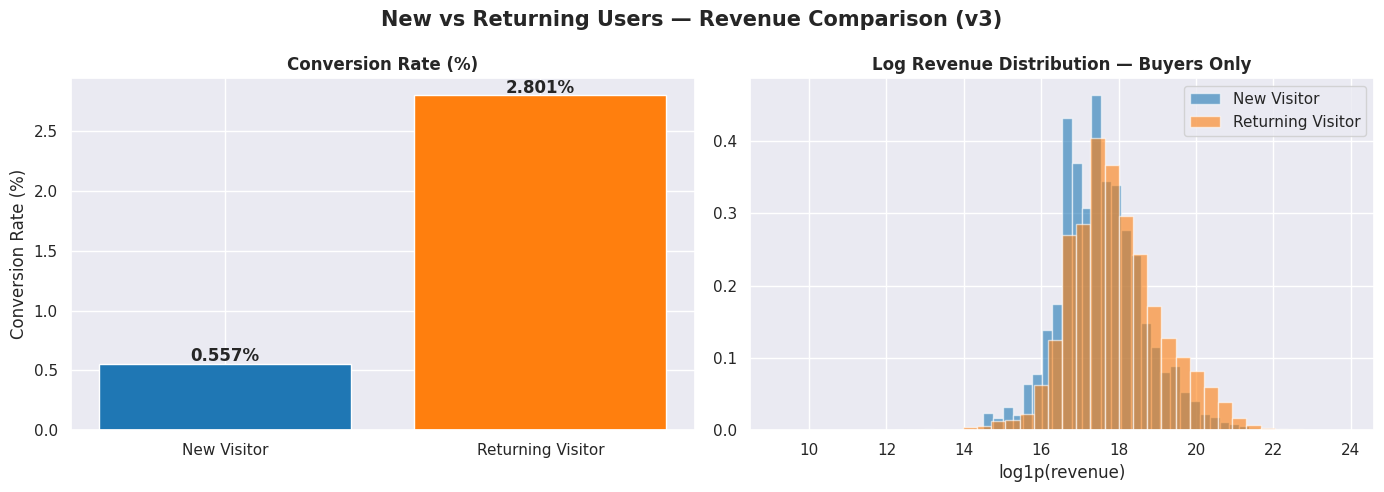


💡 Business Insight:
   Returning visitors have a dramatically higher conversion rate.
   This is the core signal for Phase 3 user-level aggregation.
   visitNumber and total prior sessions are critical features.


In [17]:
if 'totals.newVisits' in train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('New vs Returning Users — Revenue Comparison (v3)',
                 fontsize=15, fontweight='bold')

    train['visitor_type'] = train['totals.newVisits'].apply(
        lambda x: 'New Visitor' if x == 1 else 'Returning Visitor'
    )

    # Conversion rate
    vtype_conv = train.groupby('visitor_type').apply(
        lambda x: (x['revenue'] > 0).mean() * 100
    )
    axes[0].bar(vtype_conv.index, vtype_conv.values, color=['#1f77b4', '#ff7f0e'])
    axes[0].set_title('Conversion Rate (%)', fontweight='bold')
    axes[0].set_ylabel('Conversion Rate (%)')
    for i, v in enumerate(vtype_conv.values):
        axes[0].text(i, v + 0.02, f'{v:.3f}%', ha='center', fontweight='bold')

    # Revenue distribution (log scale, buyers only)
    for vtype, color in [('New Visitor', '#1f77b4'), ('Returning Visitor', '#ff7f0e')]:
        rev_data = train[(train['visitor_type'] == vtype) & (train['revenue'] > 0)]['log_revenue']
        axes[1].hist(rev_data, bins=40, alpha=0.6, color=color, label=vtype, density=True)
    axes[1].set_title('Log Revenue Distribution — Buyers Only', fontweight='bold')
    axes[1].set_xlabel('log1p(revenue)')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_PATH + 'plot_08_new_vs_returning.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n💡 Business Insight:')
    print('   Returning visitors have a dramatically higher conversion rate.')
    print('   This is the core signal for Phase 3 user-level aggregation.')
    print('   visitNumber and total prior sessions are critical features.')

### 6.9 — 🆕 OS × Device Interaction

> **New in v3.** Don't just look at Mobile vs Desktop — look at the combination.  
> iOS users often have higher average order values than Android users.

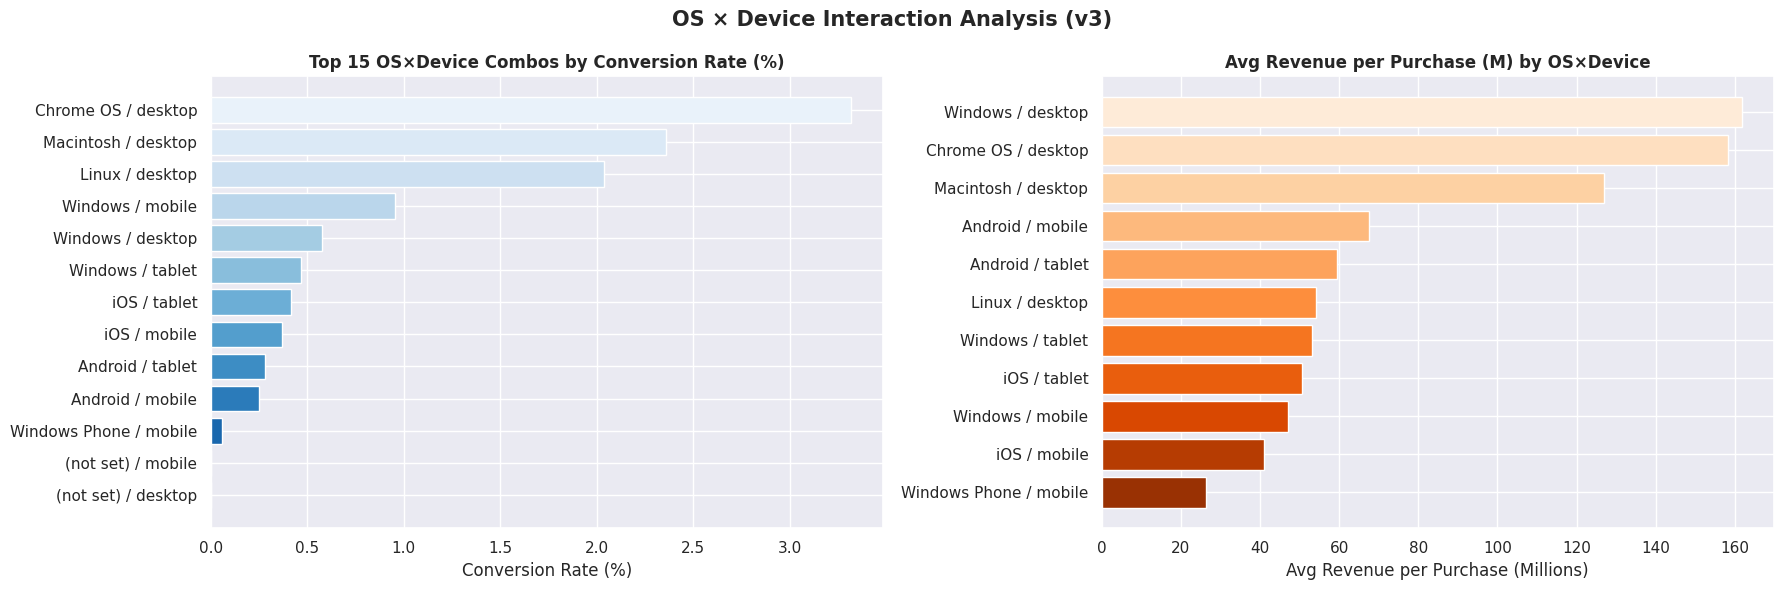


💡 Business Insight:
   Specific OS×Device combos reveal high-value user segments.
   Consider creating is_high_value_device Boolean feature for Phase 3.


In [18]:
if 'device.operatingSystem' in train.columns and 'device.deviceCategory' in train.columns:
    # Create OS × Device combination
    train['os_device'] = (
        train['device.operatingSystem'].astype(str) + ' / '
        + train['device.deviceCategory'].astype(str)
    )

    os_dev_stats = train.groupby('os_device').agg(
        visits=('revenue', 'count'),
        conv_rate=('revenue', lambda x: (x > 0).mean() * 100),
        avg_rev_buyers=('revenue', lambda x: x[x > 0].mean() if (x > 0).any() else 0)
    ).reset_index()

    # Filter to combos with at least 1,000 visits for statistical reliability
    os_dev_stats = os_dev_stats[os_dev_stats['visits'] >= 1000].sort_values(
        'conv_rate', ascending=False
    ).head(15)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('OS × Device Interaction Analysis (v3)', fontsize=15, fontweight='bold')

    axes[0].barh(os_dev_stats['os_device'][::-1], os_dev_stats['conv_rate'][::-1],
                 color=sns.color_palette('Blues_r', len(os_dev_stats)))
    axes[0].set_title('Top 15 OS×Device Combos by Conversion Rate (%)', fontweight='bold')
    axes[0].set_xlabel('Conversion Rate (%)')

    os_dev_stats_rev = os_dev_stats[os_dev_stats['avg_rev_buyers'] > 0].sort_values(
        'avg_rev_buyers', ascending=False
    )
    axes[1].barh(os_dev_stats_rev['os_device'][::-1],
                 os_dev_stats_rev['avg_rev_buyers'][::-1] / 1e6,
                 color=sns.color_palette('Oranges_r', len(os_dev_stats_rev)))
    axes[1].set_title('Avg Revenue per Purchase (M) by OS×Device', fontweight='bold')
    axes[1].set_xlabel('Avg Revenue per Purchase (Millions)')

    plt.tight_layout()
    plt.savefig(OUTPUT_PATH + 'plot_09_os_device_interaction.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n💡 Business Insight:')
    print('   Specific OS×Device combos reveal high-value user segments.')
    print('   Consider creating is_high_value_device Boolean feature for Phase 3.')

---
## 💾 Section 7 — Save Processed Datasets

In [19]:
# ── Drop non-CSV-serializable columns ────────────────────────────────────────
cols_to_drop_save = ['year_month', 'visitor_type', 'os_device']
train_save = train.drop(columns=[c for c in cols_to_drop_save if c in train.columns])

# ── Save ─────────────────────────────────────────────────────────────────────
train_out = OUTPUT_PATH + 'train_clean_v3.csv'
test_out  = OUTPUT_PATH + 'test_clean_v3.csv'

print('💾 Saving processed files...')
train_save.to_csv(train_out, index=False)
print(f'   ✅ train_clean_v3.csv  →  {os.path.getsize(train_out)/1e6:.1f} MB  |  shape: {train_save.shape}')

test.to_csv(test_out, index=False)
print(f'   ✅ test_clean_v3.csv   →  {os.path.getsize(test_out)/1e6:.1f} MB  |  shape: {test.shape}')

print('\n✅ Phase 1 + 2 (v3) complete. Outputs saved to /kaggle/working/')

# Final memory cleanup
gc.collect()

💾 Saving processed files...
   ✅ train_clean_v3.csv  →  601.5 MB  |  shape: (1708337, 47)
   ✅ test_clean_v3.csv   →  135.1 MB  |  shape: (401589, 44)

✅ Phase 1 + 2 (v3) complete. Outputs saved to /kaggle/working/


0

---
## 📋 Section 8 — Phase Summary

| Step | Action | Status |
|---|---|---|
| Memory-efficient load | Chunks of 50k rows | ✅ |
| `hits` signal extraction | `hits_interaction_count` + `hits_max_ecommerce_action` | ✅ 🆕 |
| JSON flattening | `device`, `geoNetwork`, `totals`, `trafficSource` | ✅ |
| Revenue target | `log1p(transactionRevenue)` | ✅ |
| Constant columns dropped | Zero-variance features removed | ✅ |
| Type conversion | Numeric strings fixed | ✅ |
| Smart imputation | Conditional fills based on bounce status | ✅ 🆕 |
| Micro-temporal features | `visit_hour`, `visit_weekday`, `is_weekend`, `is_business_hours` | ✅ 🆕 |
| EDA — 9 plots | Revenue, Channel, Device, Geo, Time, Behavior, Temporal/Funnel, New vs Returning, OS×Device | ✅ |
| Output saved | `train_clean_v3.csv` + `test_clean_v3.csv` | ✅ |

---

### 🔑 Key Findings

1. **~98% zero revenue** — Zero-inflation is the core challenge of this competition
2. **Direct & Organic Search** drive the most revenue
3. **Desktop** has the highest conversion rate despite lower visit share
4. **Q4 holiday seasonality** is clearly visible in monthly revenue
5. **Engaged users buy more** — pageviews, hits, and eCommerceAction funnel stage strongly correlate with purchasing
6. **Bounced sessions almost never convert** — bounce flag is a strong negative signal
7. **Returning visitors convert far more often** — visit recency and frequency are key Phase 3 features
8. **eCommerce funnel depth** (Add to Cart → Checkout) is the strongest session-level predictor of future revenue
9. **OS × Device combos** reveal distinct high-value user segments

---

### ➡️ Next: Phase 3 — User-Level Feature Aggregation

Collapse all session rows into **one row per user** and build:
- **RFM features**: Recency (days since last visit), Frequency (# sessions), Monetary (total historical revenue)
- **Behavioral aggregations**: `std(timeOnSite)`, `max(pageviews)`, `mean(hits_interaction_count)`
- **Funnel aggregations**: `max(hits_max_ecommerce_action)` per user — highest purchase intent signal
- **Time-based split**: Use months 1–5 to predict months 7–8 for validation (no random splits!)

```
⚠️  Validation Setup Warning:
    DO NOT use train_test_split. Use a temporal split:
    Train   : sessions in months 1–5  →  predict revenue in months 7–8
    Validate: sessions in months 6–10 →  predict revenue in months 12–13
```